# 06. Association Rules (Khai phá Luật kết hợp)

**Mục tiêu:**
- Sử dụng Basket Matrix (one-hot encoding) theo **StockCode**.
- Đánh giá và so sánh hai thuật toán: **Apriori** và **FP-Growth**.
- Sinh các luật kết hợp với min_support và min_confidence.
- Lọc các luật có ý nghĩa (Lift > 1) và đề xuất **Business Insights** (Cross-selling).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from src.config import PROCESSED_DIR, TABLES_ASSOCIATION, FIGURES_ASSOCIATION
from src.association_rules import (
    load_basket_matrix, load_basket_from_long, map_stockcode_to_description,
    run_apriori, run_fpgrowth, generate_rules, validate_rules, build_algorithm_comparison, frozenset_to_names
)
from src.visualization import (
    plot_top_products, plot_algorithm_comparison, plot_scatter_support_confidence_lift, plot_top_rules_by_lift
)

RULES_TBL_DIR = TABLES_ASSOCIATION / 'association_rules'

%matplotlib inline

## 1. Tải và Xác thực Basket Matrix

Loading basket matrix from D:\Project\Data-mininng\data\processed\association_basket_matrix.csv...


  Invoices: 19,773
  Products: 3,908
  Avg items/invoice: 26.16
  Sparsity: 0.9933


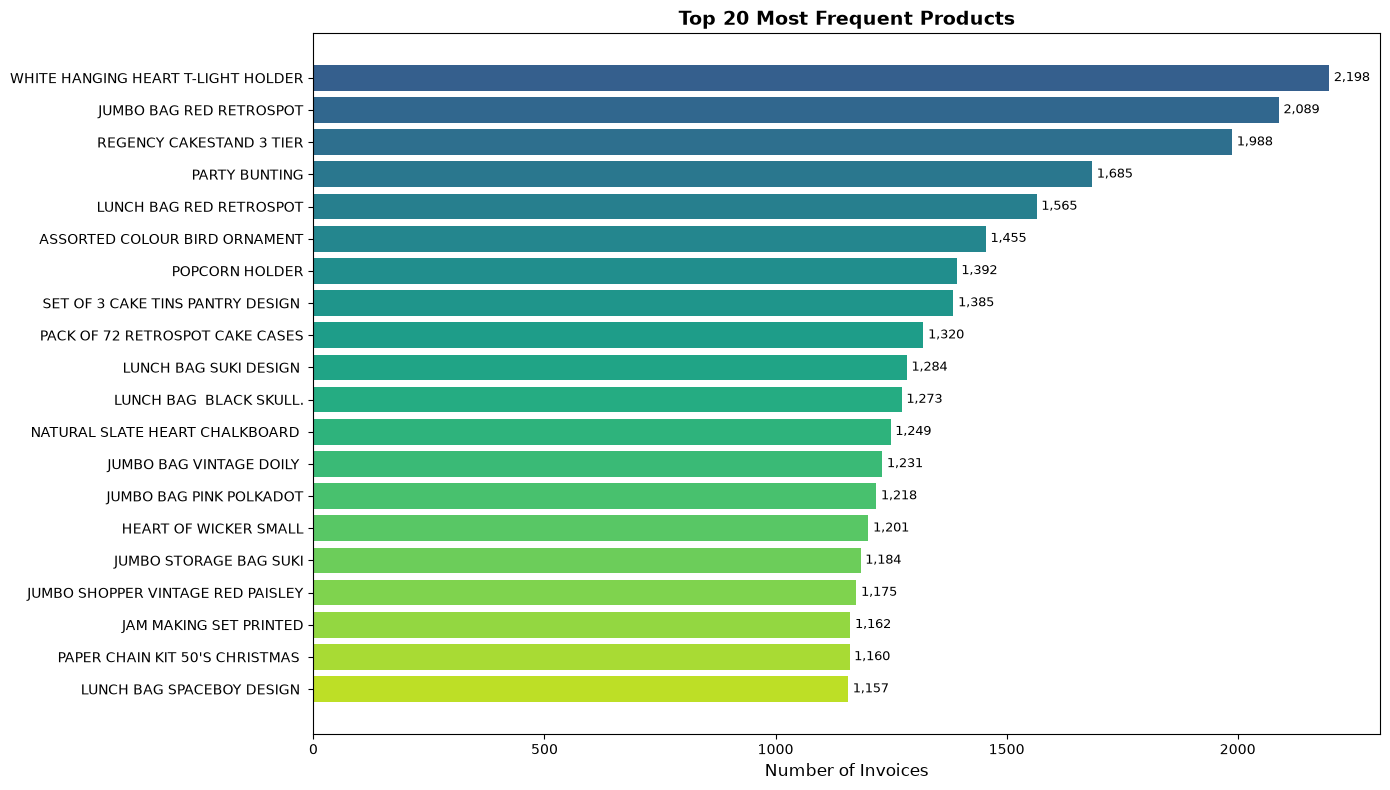

In [2]:
basket_matrix_path = PROCESSED_DIR / 'association_basket_matrix.csv'
basket_long_path = PROCESSED_DIR / 'association_basket_long.csv'

if basket_matrix_path.exists():
    basket, stats = load_basket_matrix(basket_matrix_path)
else:
    basket, stats = load_basket_from_long(basket_long_path)

sc_to_desc = map_stockcode_to_description(basket_long_path)
product_freq = basket.sum(axis=0).sort_values(ascending=False)

plot_top_products(product_freq, sc_to_desc, stats['n_invoices'])

## 2. So sánh Apriori và FP-Growth

Tham số: min_support=0.02, min_confidence=0.5
  Running Apriori (min_support=0.02)...


  Apriori: 389 frequent itemsets in 3.88s
  Running FP-Growth (min_support=0.02)...


  FP-Growth: 389 frequent itemsets in 3.86s
Apriori Runtime: 3.88s | FP-Growth Runtime: 3.86s


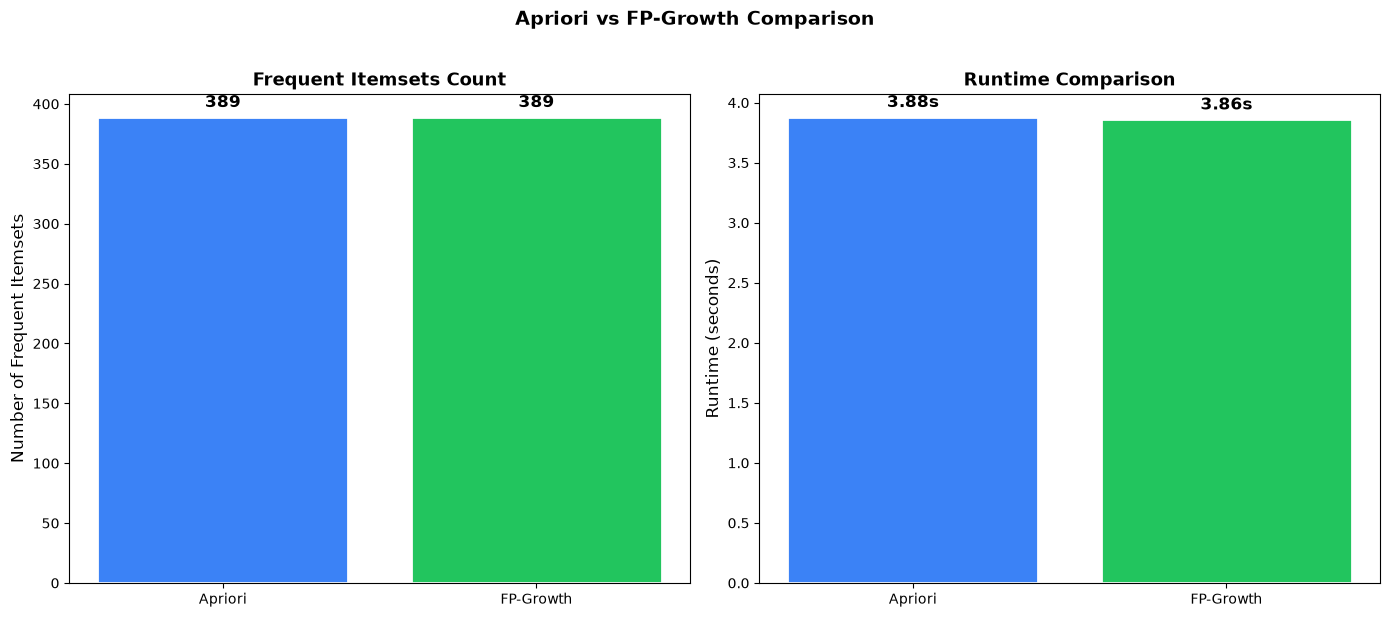

In [3]:
min_support = 0.02
min_confidence = 0.5

print(f"Tham số: min_support={min_support}, min_confidence={min_confidence}")

# Run Apriori
try:
    apriori_itemsets, apriori_time = run_apriori(basket, min_support=min_support)
except:
    print("Apriori failed at 0.02, trying 0.03")
    min_support = 0.03
    apriori_itemsets, apriori_time = run_apriori(basket, min_support=min_support)

# Run FP-Growth
fpgrowth_itemsets, fpgrowth_time = run_fpgrowth(basket, min_support=min_support)

print(f"Apriori Runtime: {apriori_time:.2f}s | FP-Growth Runtime: {fpgrowth_time:.2f}s")
plot_algorithm_comparison(apriori_itemsets, fpgrowth_itemsets, apriori_time, fpgrowth_time)

## 3. Sinh Luật (Generate Rules) và Xác thực (Validate)
Xác thực cả hai thuật toán (kiểm tra Lift > 1, chống giao thoa, chống empty, loại NaN).

In [4]:
apriori_rules = generate_rules(apriori_itemsets, min_confidence=min_confidence)
fpgrowth_rules = generate_rules(fpgrowth_itemsets, min_confidence=min_confidence)

apriori_valid, apriori_checks = validate_rules(apriori_rules, min_support, min_confidence)
fpgrowth_valid, fpgrowth_checks = validate_rules(fpgrowth_rules, min_support, min_confidence)

print("Apriori Validations:")
for c in apriori_checks: print(f"  {c}")
    
print("\nFP-Growth Validations:")
for c in fpgrowth_checks: print(f"  {c}")

apriori_lift = apriori_valid[apriori_valid['lift'] > 1].copy()
fpgrowth_lift = fpgrowth_valid[fpgrowth_valid['lift'] > 1].copy()
print(f"\nRules hợp lệ (Lift > 1) -> Apriori: {len(apriori_lift)}, FP-Growth: {len(fpgrowth_lift)}")

Apriori Validations:
  [OK] support >= 0.02: 61/61 rules
  [OK] confidence >= 0.5: 61 rules
  [OK] lift > 1: 61/61 rules
  [OK] Empty antecedent: 0, Empty consequent: 0
  [OK] Antecedent-consequent overlap: 0
  [OK] NaN in metrics: 0, Inf: 0
  [OK] Duplicates removed: 0

FP-Growth Validations:
  [OK] support >= 0.02: 61/61 rules
  [OK] confidence >= 0.5: 61 rules
  [OK] lift > 1: 61/61 rules
  [OK] Empty antecedent: 0, Empty consequent: 0
  [OK] Antecedent-consequent overlap: 0
  [OK] NaN in metrics: 0, Inf: 0
  [OK] Duplicates removed: 0

Rules hợp lệ (Lift > 1) -> Apriori: 61, FP-Growth: 61


## 4. Lựa chọn thuật toán & Lưu kết quả
Lựa chọn **FP-Growth** làm thuật toán chính vì có thời gian chạy nhanh hơn mà vẫn tạo ra số luật tương đương (Apriori được dùng làm baseline).

In [5]:
def max_itemset_size(df): return int(df['itemsets'].apply(len).max()) if not df.empty else 0

apriori_info = {'algorithm': 'Apriori', 'min_support': min_support, 'min_confidence': min_confidence, 'runtime': apriori_time, 'n_itemsets': len(apriori_itemsets), 'n_rules': len(apriori_rules), 'n_valid_rules': len(apriori_lift), 'max_itemset_size': max_itemset_size(apriori_itemsets), 'max_lift': apriori_lift['lift'].max() if len(apriori_lift)>0 else 0}
fpgrowth_info = {'algorithm': 'FP-Growth', 'min_support': min_support, 'min_confidence': min_confidence, 'runtime': fpgrowth_time, 'n_itemsets': len(fpgrowth_itemsets), 'n_rules': len(fpgrowth_rules), 'n_valid_rules': len(fpgrowth_lift), 'max_itemset_size': max_itemset_size(fpgrowth_itemsets), 'max_lift': fpgrowth_lift['lift'].max() if len(fpgrowth_lift)>0 else 0}

algo_comp = build_algorithm_comparison(apriori_info, fpgrowth_info)
display(algo_comp)
algo_comp.to_csv(TABLES_ASSOCIATION / 'association_algorithm_comparison.csv', index=False)

def save_rules_csv(rules, algorithm, filepath):
    if rules.empty:
        pd.DataFrame().to_csv(filepath, index=False)
        return
    df = rules.copy()
    df['antecedents_str'] = df['antecedents'].apply(lambda x: frozenset_to_names(x, sc_to_desc))
    df['consequents_str'] = df['consequents'].apply(lambda x: frozenset_to_names(x, sc_to_desc))
    df['antecedents_codes'] = df['antecedents'].apply(lambda x: ', '.join(sorted(x)))
    df['consequents_codes'] = df['consequents'].apply(lambda x: ', '.join(sorted(x)))
    df['algorithm'] = algorithm
    cols = ['antecedents_str', 'consequents_str', 'antecedents_codes', 'consequents_codes', 'antecedent_length', 'consequent_length', 'support', 'confidence', 'lift', 'algorithm']
    if 'leverage' in df.columns: cols.append('leverage')
    if 'conviction' in df.columns: cols.append('conviction')
    df[cols].to_csv(filepath, index=False)

save_rules_csv(apriori_lift, 'Apriori', RULES_TBL_DIR / 'apriori_rules.csv')
save_rules_csv(fpgrowth_lift, 'FP-Growth', RULES_TBL_DIR / 'fpgrowth_rules.csv')
save_rules_csv(fpgrowth_lift, 'FP-Growth', RULES_TBL_DIR / 'selected_association_rules.csv')

,algorithm,min_support,min_confidence,runtime_seconds,frequent_itemset_count,rule_count,valid_rule_count,max_itemset_size,max_rule_lift
0,Apriori,0.02,0.5,3.88,389,61,61,3,18.231107
1,FP-Growth,0.02,0.5,3.86,389,61,61,3,18.231107


## 5. Trực quan hóa Rules

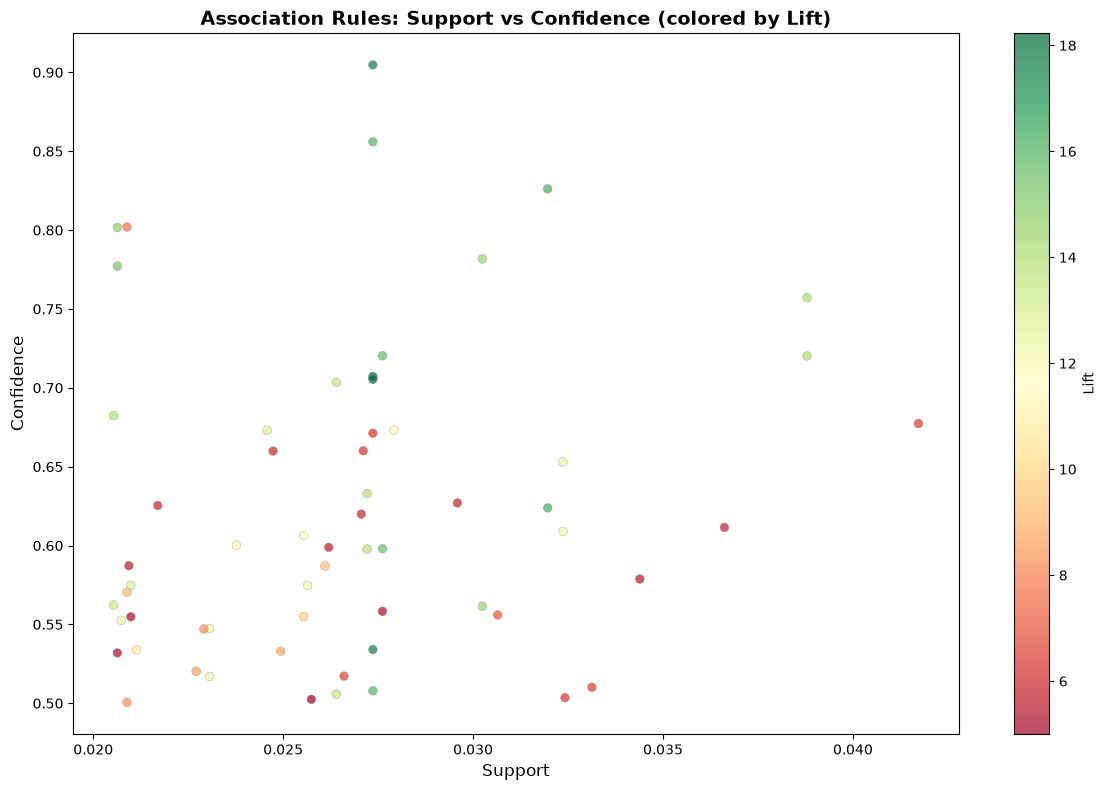

In [6]:
plot_scatter_support_confidence_lift(fpgrowth_lift)

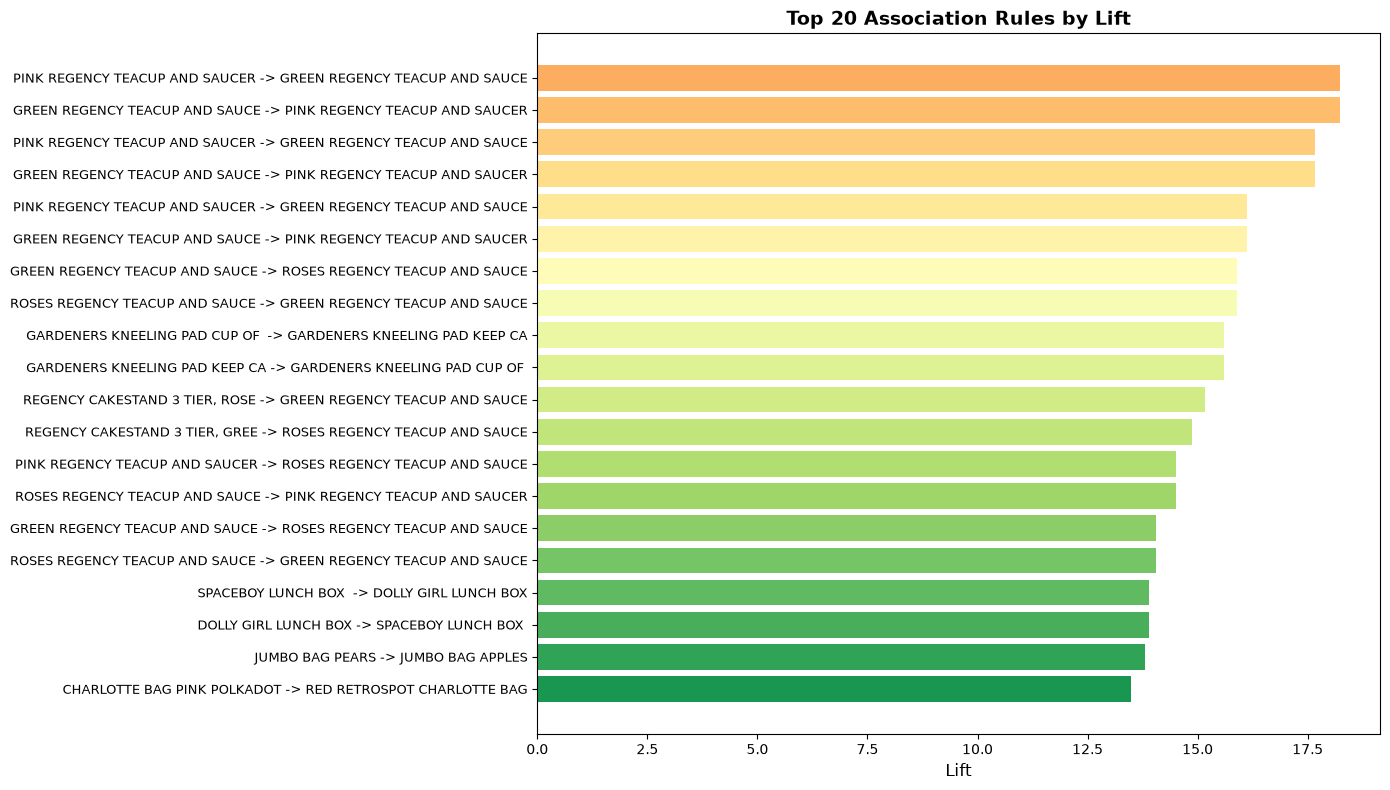

In [7]:
plot_top_rules_by_lift(fpgrowth_lift, sc_to_desc, frozenset_to_names)

## 6. Business Insights (Gợi ý kinh doanh)
Lấy top 5 luật tốt nhất dựa trên Tích `Lift * Confidence` để tư vấn Cross-selling.
*Lưu ý: Khai phá luật chỉ chứng minh sự đồng xuất hiện (co-occurrence) chứ không mang tính nhân quả (causality).*

In [8]:
top_rules = fpgrowth_lift.copy()
top_rules['quality'] = top_rules['lift'] * top_rules['confidence']
top_rules = top_rules.nlargest(min(10, len(top_rules)), 'quality')

insights = []
for i, (_, rule) in enumerate(top_rules.head(5).iterrows()):
    ant_names = frozenset_to_names(rule['antecedents'], sc_to_desc)
    con_names = frozenset_to_names(rule['consequents'], sc_to_desc)
    
    print(f"Insight #{i+1}: Khách hàng mua '{ant_names}' thì rất dễ mua thêm '{con_names}'")
    print(f"  - Support: {rule['support']:.4f} (~{int(rule['support'] * stats['n_invoices'])} hóa đơn)")
    print(f"  - Confidence: {rule['confidence']:.4f} (Xác suất {rule['confidence']*100:.1f}%)")
    print(f"  - Lift: {rule['lift']:.4f} -> Khuyến nghị tạo COMBO Cross-selling.\n")
    
    insights.append({
        'rank': i + 1, 'antecedent': ant_names, 'consequent': con_names,
        'support': round(rule['support'], 4), 'confidence': round(rule['confidence'], 4), 'lift': round(rule['lift'], 4),
    })

pd.DataFrame(insights).to_csv(TABLES_ASSOCIATION / 'association_business_insights.csv', index=False)

Insight #1: Khách hàng mua 'PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER ' thì rất dễ mua thêm 'GREEN REGENCY TEACUP AND SAUCER'
  - Support: 0.0274 (~541 hóa đơn)
  - Confidence: 0.9047 (Xác suất 90.5%)
  - Lift: 17.6587 -> Khuyến nghị tạo COMBO Cross-selling.

Insight #2: Khách hàng mua 'GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER' thì rất dễ mua thêm 'ROSES REGENCY TEACUP AND SAUCER '
  - Support: 0.0274 (~541 hóa đơn)
  - Confidence: 0.8560 (Xác suất 85.6%)
  - Lift: 15.8929 -> Khuyến nghị tạo COMBO Cross-selling.

Insight #3: Khách hàng mua 'PINK REGENCY TEACUP AND SAUCER' thì rất dễ mua thêm 'GREEN REGENCY TEACUP AND SAUCER'
  - Support: 0.0320 (~632 hóa đơn)
  - Confidence: 0.8261 (Xác suất 82.6%)
  - Lift: 16.1257 -> Khuyến nghị tạo COMBO Cross-selling.

Insight #4: Khách hàng mua 'PINK REGENCY TEACUP AND SAUCER' thì rất dễ mua thêm 'GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER '
  - Support: 0.0274 (~541 hóa đơn)
  - C